Model Comparison and Evaluation

In [ ]:
# Importing required libraries

import pandas as pd
import joblib

In [ ]:
# Loading data for Logistic model

df1 = pd.read_csv('processed_churn.csv')

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customerID        7032 non-null   int64
 1   gender            7032 non-null   int64
 2   SeniorCitizen     7032 non-null   int64
 3   Partner           7032 non-null   int64
 4   Dependents        7032 non-null   int64
 5   MultipleLines     7032 non-null   int64
 6   InternetService   7032 non-null   int64
 7   OnlineSecurity    7032 non-null   int64
 8   OnlineBackup      7032 non-null   int64
 9   DeviceProtection  7032 non-null   int64
 10  TechSupport       7032 non-null   int64
 11  StreamingTV       7032 non-null   int64
 12  StreamingMovies   7032 non-null   int64
 13  Contract          7032 non-null   int64
 14  PaperlessBilling  7032 non-null   int64
 15  PaymentMethod     7032 non-null   int64
 16  Churn             7032 non-null   int64
dtypes: int64(17)
memory usage: 934.1 

In [ ]:
x = df1.drop('Churn', axis=1)
y = df1['Churn']

In [ ]:
# Checking if the data is balanced or unbalanced.

print(y.value_counts(normalize=True) * 100)

# Majority class > 70
# Therefire, unbalanced data

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
# Scaling data dor Logistic Regression model

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# Preforming Regularization, GridSearchCV for LR model to pick the best parameters suited.

param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear'],
        'class_weight': [None, 'balanced']}

grid_l = GridSearchCV(LogisticRegression(max_iter=5000, random_state=42),param_grid=param_grid,
        cv=5,
        scoring='f1')

grid_l.fit(x_train_scaled,y_train)

print("\nBest LR Params:", grid_l.best_params_)
print("Best LR F1:", grid_l.best_score_)

model_lr = grid_l.best_estimator_


Best LR Params: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
Best LR F1: 0.6069003044523238


In [ ]:
# Loading data for Tree models

df2 = pd.read_csv('clean_churn.csv')

In [ ]:
X = df1.drop('Churn', axis=1)
Y = df1['Churn']

In [ ]:
print(y.value_counts(normalize=True) * 100)

# Majority class > 70
# Therefore, unbalanced data.

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state = 42, stratify = Y)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Performing GridSearchCV for Decision Tree

params = {
    'max_depth': [2,3,4,5,7],
    'min_samples_split': [2,3,4,5],
    'min_samples_leaf': [2,4,5]}

grid_d = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid = params, cv = 5,scoring='f1')

grid_d.fit(X_train,Y_train)

print("\nBest LR Params:", grid_d.best_params_)
print("Best LR F1:", grid_d.best_score_)

model_dt = grid_d.best_estimator_


Best LR Params: {'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best LR F1: 0.6018470462723031


In [ ]:
# Performing GridSaerchCV for Random Forest model

param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3,4,5,10],
        'min_samples_leaf': [1, 2, 4],
        'min_samples_split': [2, 5, 10],
        'criterion': ['gini', 'entropy']}

grid_r = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
  param_grid=param_grid,
  cv=5,
  scoring='f1')

grid_r.fit(X_train, y_train)

print("\nBest RF Parameters:", grid_r.best_params_)
print("Best RF F1:", grid_r.best_score_)

model_rf = grid_r.best_estimator_


Best RF Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Best RF F1: 0.534693411707527


In [33]:
model_lr.fit(x_train_scaled,y_train)

LogisticRegression(C=0.01, class_weight='balanced', max_iter=5000,
                   random_state=42)

In [34]:
model_dt.fit(X_train,Y_train)

DecisionTreeClassifier(max_depth=2, min_samples_leaf=2, random_state=42)

In [35]:
model_rf.fit(X_train,Y_train)

RandomForestClassifier(criterion='entropy', max_depth=10, min_samples_leaf=2,
                       min_samples_split=10, n_jobs=-1, random_state=42)

In [42]:
joblib.dump(model_lr, 'logistic_model.pkl')
joblib.dump(model_dt, 'decision_tree_model.pkl')
joblib.dump(model_rf, 'random_forest_model.pkl')

from google.colab import files
files.download('logistic_model.pkl')
files.download('decision_tree_model.pkl')
files.download('random_forest_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
pred_lr = model_lr.predict(x_test_scaled)
pred_dt = model_dt.predict(X_test)
pred_rf = model_rf.predict(X_test)

In [43]:
# Comparing models on the basis of classification evaluation metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(Y_test, pred_dt),
        accuracy_score(Y_test, pred_rf)
    ],
    "Precision": [
        precision_score(y_test, pred_lr),
        precision_score(Y_test, pred_dt),
        precision_score(Y_test, pred_rf)
    ],
    "Recall": [
        recall_score(y_test, pred_lr),
        recall_score(Y_test, pred_dt),
        recall_score(Y_test, pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, pred_lr),
        f1_score(Y_test, pred_dt),
        f1_score(Y_test, pred_rf)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.697939   0.460949  0.804813  0.586173
1        Decision Tree  0.728500   0.492481  0.700535  0.578366
2        Random Forest  0.773276   0.589577  0.483957  0.531571


**Conclusion**

Although Random Forest achieved the highest accuracy, its recall was significantly lower, indicating poor detection of the minority class. Logistic Regression obtained the highest F1-score and the highest recall, demonstrating a better balance between precision and recall. Therefore, Logistic Regression was selected as the best performing model for this dataset

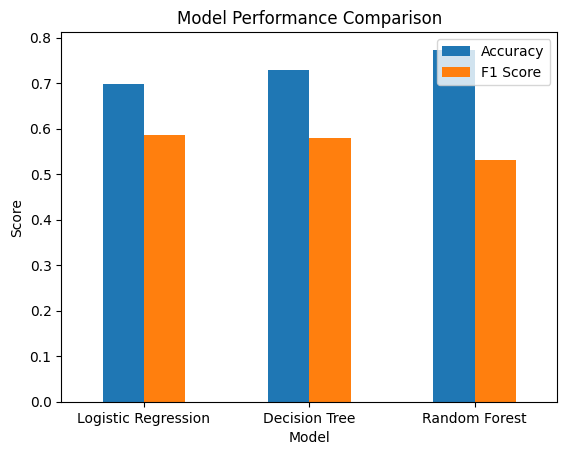

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

results.set_index("Model")[["Accuracy","F1 Score"]].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

Although Random Forest achieved the highest accuracy, its lower F1 score indicates poor minority class detection, while Logistic Regression maintained the best balance between precision and recall, making it more reliable for churn prediction.

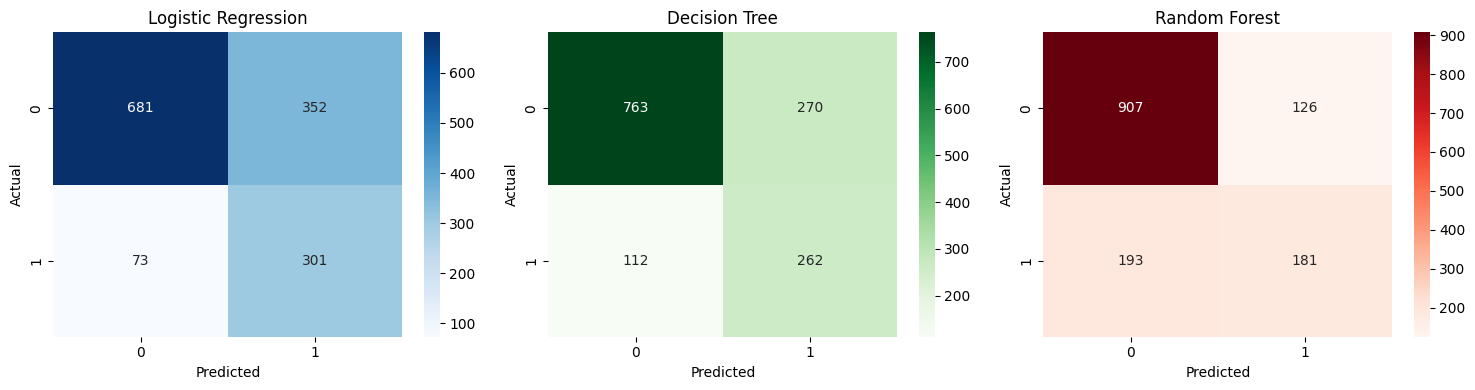

In [53]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# predictions
pred_lr = model_lr.predict(x_test_scaled)
pred_dt = model_dt.predict(X_test)
pred_rf = model_rf.predict(X_test)

# confusion matrices
cm_lr = confusion_matrix(y_test, pred_lr)
cm_dt = confusion_matrix(Y_test, pred_dt)
cm_rf = confusion_matrix(Y_test, pred_rf)

fig, axes = plt.subplots(1,3, figsize=(15,4))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Decision Tree")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', ax=axes[2])
axes[2].set_title("Random Forest")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

- The Logistic Regreesion model detects the most churn customers but produces more false alarms.
- Decision Tree makes more balanced predictions but misses some churn cases.
- Random Forest predicts non-churn very well but misses many churn customers.

Logistic Regression detects the most churn cases, Decision Tree is moderately balanced, and Random Forest mainly predicts non-churn customers, explaining its high accuracy but low recall.




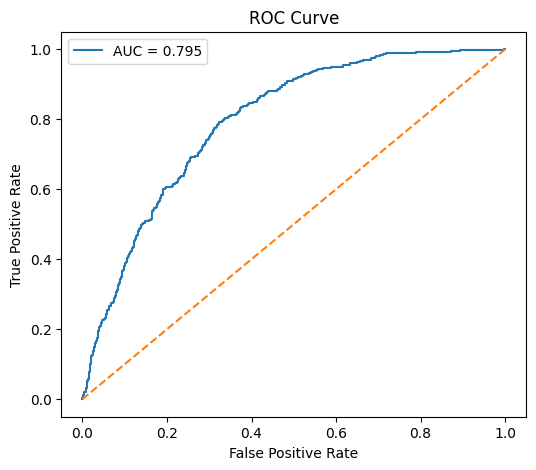

In [48]:
from sklearn.metrics import roc_curve, roc_auc_score

probs = model_lr.predict_proba(x_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The ROC curve shows good class discrimination ability, as the model performs significantly better than random guessing and can distinguish churn from non-churn customers across thresholds.

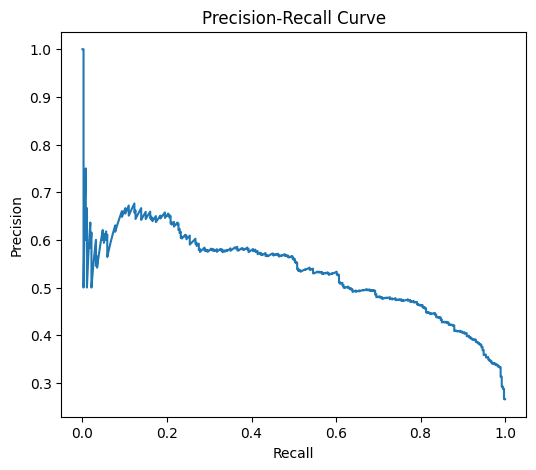

In [49]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, probs)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

Precision decreases gradually as recall increases, indicating the dataset contains overlapping class characteristics where detecting more churn customers introduces additional false positives, which is typical in real-world churn prediction problems.

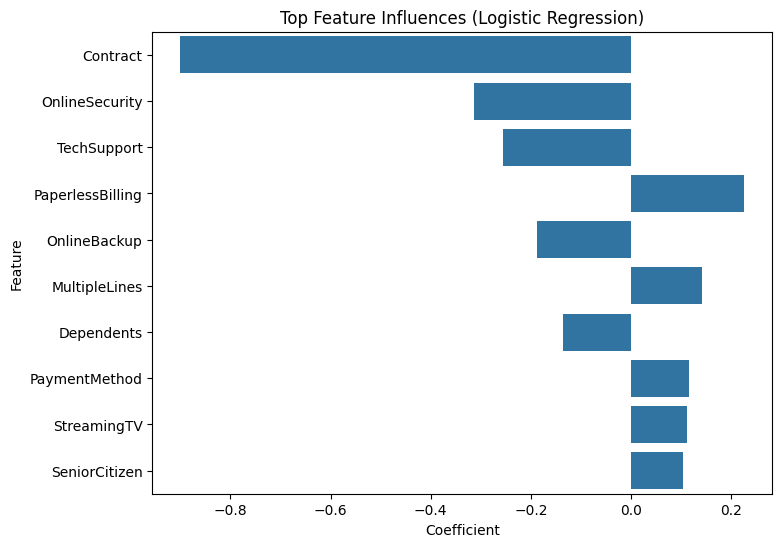

In [51]:
import numpy as np

feature_names = x_train.columns
coeff = model_lr.coef_[0]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coeff
})

importance = importance.sort_values(by="Coefficient", key=abs, ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=importance.head(10), x="Coefficient", y="Feature")
plt.title("Top Feature Influences (Logistic Regression)")
plt.show()

Contract type has the strongest negative influence on churn, while services such as paperless billing and multiple lines increase churn likelihood, indicating customer commitment and service usage patterns strongly affect retention.

The dataset exhibits moderate class overlap, and the simpler Logistic Regression model generalizes better by capturing overall behavioral trends, whereas tree-based models tend to bias toward the majority class.